In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import os

dataset_path = "/content/drive/MyDrive/Facial-Skin-Analysis/Dataset"

print("Folders in Dataset: ")
print(os.listdir(dataset_path))

Folders in Dataset: 
['clear skin', 'dark spots', 'puffy eyes', 'wrinkles']


In [5]:
import tensorflow as tf

train_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(224, 224),
    batch_size=32
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(224, 224),
    batch_size=32
)

Found 1203 files belonging to 4 classes.
Using 963 files for training.
Found 1203 files belonging to 4 classes.
Using 240 files for validation.


In [6]:
class_names = train_dataset.class_names
print(class_names)

['clear skin', 'dark spots', 'puffy eyes', 'wrinkles']


In [7]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)

validation_dataset = validation_dataset.cache().prefetch(buffer_size=AUTOTUNE)

In [13]:
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

In [14]:
import tensorflow as tf
print(tf.__version__)

2.20.0


In [15]:
from tensorflow.keras.applications import MobileNetV2

model = MobileNetV2(weights="imagenet")

print("✅ MobileNetV2 loaded successfully!")

14536120/14536120 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✅ MobileNetV2 loaded successfully!


In [16]:
from tensorflow.keras import layers, models

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.2),
    layers.Dense(128, activation='relu'),
    layers.Dense(len(class_names), activation='softmax')
])

In [17]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [18]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,468 (9.24 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [19]:
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=10
)

Epoch 1/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 294s 3s/step - accuracy: 0.5628 - loss: 1.0700 - val_accuracy: 0.7125 - val_loss: 0.7499
Epoch 2/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 53s 2s/step - accuracy: 0.7113 - loss: 0.6895 - val_accuracy: 0.7083 - val_loss: 0.7729
Epoch 3/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 54s 2s/step - accuracy: 0.7404 - loss: 0.6247 - val_accuracy: 0.7833 - val_loss: 0.6002
Epoch 4/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 54s 2s/step - accuracy: 0.7965 - loss: 0.5405 - val_accuracy: 0.7292 - val_loss: 0.5851
Epoch 5/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 53s 2s/step - accuracy: 0.7944 - loss: 0.5313 - val_accuracy: 0.7708 - val_loss: 0.5823
Epoch 6/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 57s 2s/step - accuracy: 0.8100 - loss: 0.4543 - val_accuracy: 0.7792 - val_loss: 0.5414
Epoch 7/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 78s 2s/step - accuracy: 0.8079 - loss: 0.4659 - val_accuracy: 0.7917 - val_loss: 0.5429
Epoch 8/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 86s 2s/step - accuracy: 0.8401 - loss: 0.4035 - val_accuracy: 0.8042 - val_loss

In [20]:
model.save("/content/drive/MyDrive/Facial-Skin-Analysis/facial_skin_model.keras")

In [21]:
from tensorflow.keras.models import load_model

# Load the saved model
model = load_model("/content/drive/MyDrive/Facial-Skin-Analysis/facial_skin_model.keras")

print("✅ Model loaded successfully!")

✅ Model loaded successfully!


In [22]:
from google.colab import files

uploaded = files.upload()

Saving clear_skin_008.jpg to clear_skin_008.jpg


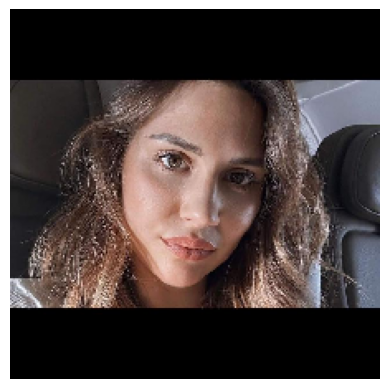

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Predicted Class: clear skin
Confidence: 99.98%


In [23]:
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# Get uploaded file name
img_path = list(uploaded.keys())[0]

# Load and resize image
img = image.load_img(img_path, target_size=(224, 224))

# Display image
plt.imshow(img)
plt.axis('off')
plt.show()

# Convert to array
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

# Predict
prediction = model.predict(img_array)

# Class names
class_names = ['clear skin', 'dark spots', 'puffy eyes', 'wrinkles']

predicted_class = class_names[np.argmax(prediction)]
confidence = np.max(prediction) * 100

print(f"Predicted Class: {predicted_class}")
print(f"Confidence: {confidence:.2f}%")

In [24]:
dataset_path = "/content/drive/MyDrive/Facial-Skin-Analysis/Datasets"